# OnePen Model Analysis

This notebook analyzes model performance and visualizes misclassified samples.

**Run this after training to:**
- See which samples the model got wrong
- Identify common confusion patterns
- Find edge cases and low-confidence predictions

In [1]:
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from collections import Counter
import json

from modifiers.utils.config import load_config

c:\Users\huybh\OneDrive\Documents\OnePen\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Load Data and Model

In [2]:
# Load config
config = load_config(Path("../config/config.yaml"))

# Load processed data
data = np.load("../data/processed/latest.npz")
images = data["images"]
features = data["features"]  
labels = data["labels"]

print(f"Images shape: {images.shape}")
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Classes: {config.classes}")

Images shape: (36712, 136, 136, 3)
Features shape: (36712, 10)
Labels shape: (36712,)
Classes: ['underline', 'box', 'curly', 'delete', 'boxshortcut', 'curlyshortcut', 'circleshortcut', 'none']


In [4]:
# Find and load the latest trained model
import glob

model_dirs = sorted(glob.glob("../outputs/run_20260111_091443/checkpoints/best_model.keras"))
if model_dirs:
    MODEL_PATH = model_dirs[-1]
    print(f"✅ Using latest model: {MODEL_PATH}")
else:
    raise FileNotFoundError("No trained model found. Run train.py first!")

model = tf.keras.models.load_model(MODEL_PATH)
print(f"Model loaded: {model.name}")

✅ Using latest model: ../outputs/run_20260111_091443/checkpoints/best_model.keras
Model loaded: hybrid_mobilenetv3_large


## Make Predictions

In [5]:
# Get predictions
predictions = model.predict(
    {"img_input": images, "feature_input": features},
    verbose=1
)
pred_labels = np.argmax(predictions, axis=1)
pred_probs = np.max(predictions, axis=1)

# Calculate accuracy
accuracy = np.mean(pred_labels == labels)
print(f"\n✅ Overall Accuracy: {accuracy:.2%}")

1148/1148 ━━━━━━━━━━━━━━━━━━━━ 207s 179ms/step

✅ Overall Accuracy: 99.80%


## Find Misclassified Samples

In [6]:
# Find all mistakes
misclassified_mask = pred_labels != labels
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total samples: {len(labels)}")
print(f"Misclassified: {len(misclassified_indices)} ({len(misclassified_indices)/len(labels):.2%})")

# Gather info about each mistake
misclassified_info = []
for idx in misclassified_indices:
    misclassified_info.append({
        "index": idx,
        "true_label": config.classes[labels[idx]],
        "pred_label": config.classes[pred_labels[idx]],
        "confidence": pred_probs[idx],
    })

# Sort by confidence (most confident mistakes first - these are interesting!)
misclassified_info.sort(key=lambda x: x["confidence"], reverse=True)

Total samples: 36712
Misclassified: 74 (0.20%)


## 📸 Visualize Misclassified Samples

These are the strokes the model got wrong. Red borders indicate mistakes.

C:\Users\huybh\AppData\Local\Temp\ipykernel_9708\1193773564.py:40: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\huybh\OneDrive\Documents\OnePen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


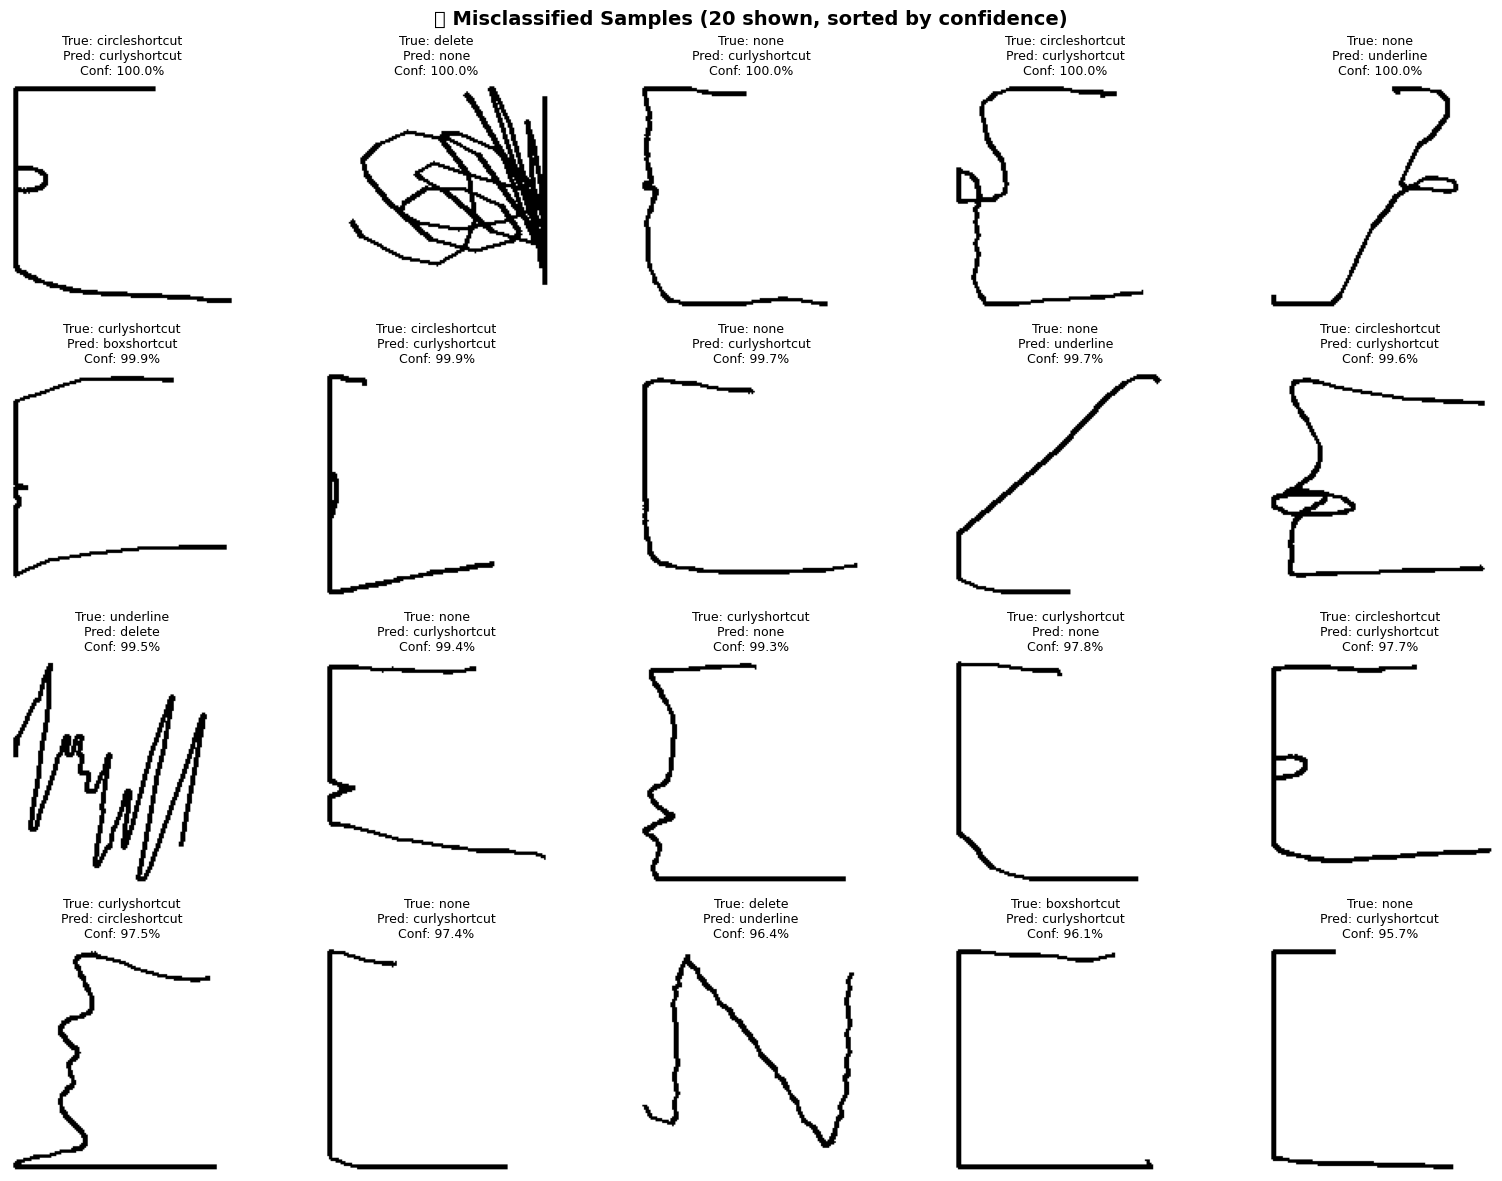

In [7]:
def plot_misclassified(info_list, images, n_samples=20, figsize=(16, 12)):
    """Plot grid of misclassified samples."""
    n = min(n_samples, len(info_list))
    if n == 0:
        print("🎉 No misclassified samples!")
        return
    
    cols = 5
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if n > 1 else [axes]
    
    for i, info in enumerate(info_list[:n]):
        ax = axes[i]
        img = images[info["index"]]
        
        if img.shape[-1] == 1:
            ax.imshow(img.squeeze(), cmap='gray')
        else:
            ax.imshow(img)
        
        # Red border for mistakes
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3)
        
        ax.set_title(
            f"True: {info['true_label']}\n"
            f"Pred: {info['pred_label']}\n"
            f"Conf: {info['confidence']:.1%}",
            fontsize=9
        )
        ax.axis('off')
    
    for i in range(n, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f"🔴 Misclassified Samples ({n} shown, sorted by confidence)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_misclassified(misclassified_info, images, n_samples=20)

## 🔴 Most Common Mistakes

Which class pairs get confused the most?

In [8]:
# Count confusion pairs
confusion_pairs = Counter()
for info in misclassified_info:
    pair = (info["true_label"], info["pred_label"])
    confusion_pairs[pair] += 1

print("🔴 Most Common Mistakes:")
print("-" * 40)
for (true, pred), count in confusion_pairs.most_common(10):
    print(f"  {true} → {pred}: {count} times")

🔴 Most Common Mistakes:
----------------------------------------
  none → curlyshortcut: 18 times
  circleshortcut → curlyshortcut: 9 times
  curlyshortcut → none: 9 times
  underline → delete: 7 times
  circleshortcut → none: 6 times
  delete → underline: 4 times
  none → underline: 3 times
  delete → none: 2 times
  curlyshortcut → boxshortcut: 2 times
  curlyshortcut → circleshortcut: 2 times


## 📊 Per-Class Error Rates

In [9]:
print("📊 Per-Class Accuracy:")
print("-" * 50)

class_stats = []
for class_idx, class_name in enumerate(config.classes):
    class_mask = labels == class_idx
    class_total = np.sum(class_mask)
    class_correct = np.sum((pred_labels == labels) & class_mask)
    class_accuracy = class_correct / class_total if class_total > 0 else 0
    
    class_stats.append((class_name, class_accuracy, class_total))
    
# Sort by accuracy
class_stats.sort(key=lambda x: x[1])

for name, acc, total in class_stats:
    bar = "█" * int(acc * 20) + "░" * (20 - int(acc * 20))
    print(f"  {name:15} {bar} {acc:.1%} (n={total})")

📊 Per-Class Accuracy:
--------------------------------------------------
  circleshortcut  ███████████████████░ 99.5% (n=2795)
  curlyshortcut   ███████████████████░ 99.6% (n=2951)
  none            ███████████████████░ 99.8% (n=11284)
  underline       ███████████████████░ 99.8% (n=4290)
  delete          ███████████████████░ 99.9% (n=5265)
  boxshortcut     ███████████████████░ 99.9% (n=2743)
  curly           ███████████████████░ 100.0% (n=2314)
  box             ███████████████████░ 100.0% (n=5070)


## ⚠️ Low Confidence Predictions

Samples the model got right but was unsure about - potential edge cases.

In [10]:
correct_mask = pred_labels == labels
correct_probs = pred_probs[correct_mask]
correct_indices = np.where(correct_mask)[0]

# Sort by confidence (ascending - least confident first)
sorted_idx = np.argsort(correct_probs)

print("⚠️ Correct but Low Confidence (potential edge cases):")
print("-" * 50)
for i in sorted_idx[:10]:
    idx = correct_indices[i]
    print(f"  {config.classes[labels[idx]]:15} - confidence: {correct_probs[i]:.1%}")

⚠️ Correct but Low Confidence (potential edge cases):
--------------------------------------------------
  curlyshortcut   - confidence: 48.2%
  none            - confidence: 50.0%
  curly           - confidence: 50.1%
  curlyshortcut   - confidence: 50.4%
  curlyshortcut   - confidence: 52.1%
  circleshortcut  - confidence: 52.4%
  boxshortcut     - confidence: 54.0%
  none            - confidence: 55.7%
  none            - confidence: 56.4%
  curlyshortcut   - confidence: 56.7%


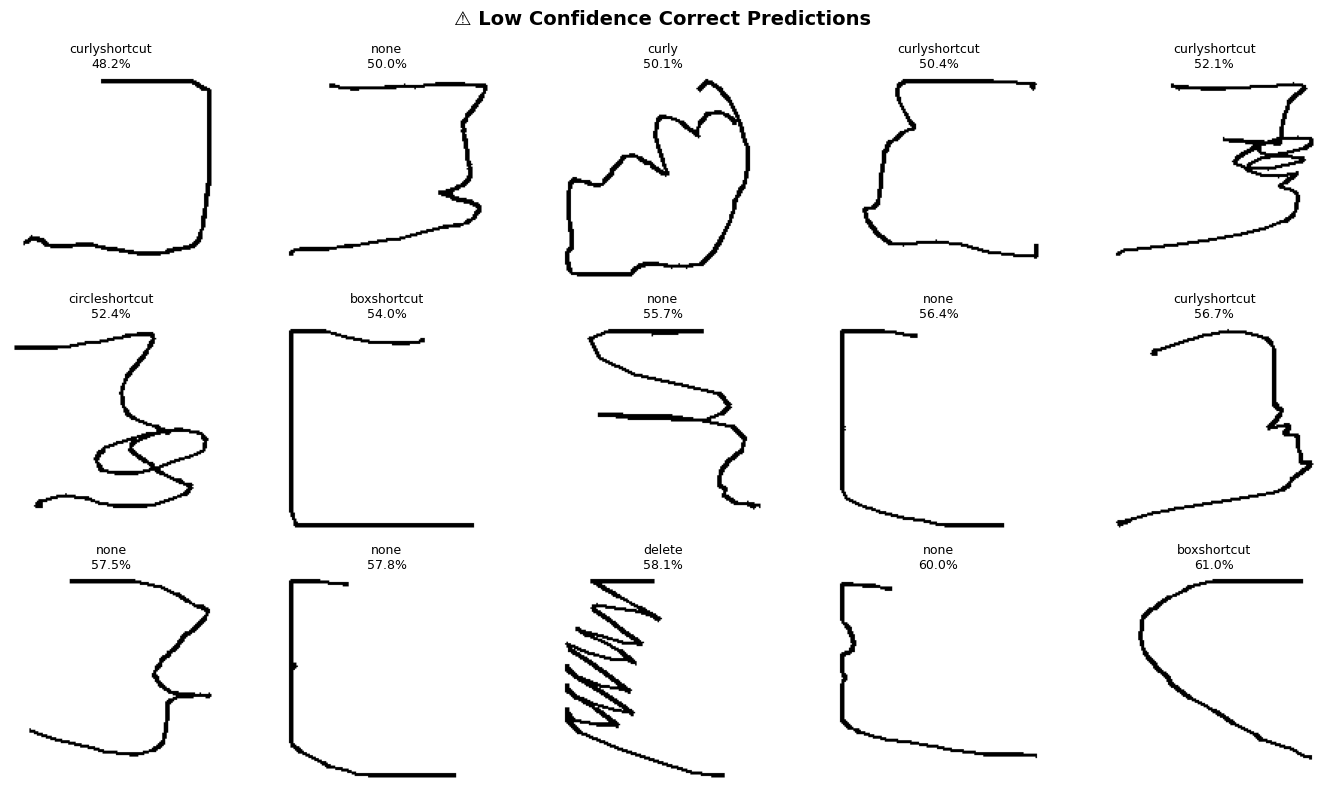

In [11]:
# Visualize low confidence correct predictions
low_conf_info = []
for i in sorted_idx[:20]:
    idx = correct_indices[i]
    low_conf_info.append({
        "index": idx,
        "true_label": config.classes[labels[idx]],
        "pred_label": config.classes[pred_labels[idx]],
        "confidence": correct_probs[i],
    })

# Reuse the plotting function
def plot_low_confidence(info_list, images, n_samples=15):
    n = min(n_samples, len(info_list))
    cols = 5
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(14, 8))
    axes = axes.flatten()
    
    for i, info in enumerate(info_list[:n]):
        ax = axes[i]
        img = images[info["index"]]
        
        if img.shape[-1] == 1:
            ax.imshow(img.squeeze(), cmap='gray')
        else:
            ax.imshow(img)
        
        # Orange border for low confidence
        for spine in ax.spines.values():
            spine.set_edgecolor('orange')
            spine.set_linewidth(3)
        
        ax.set_title(f"{info['true_label']}\n{info['confidence']:.1%}", fontsize=9)
        ax.axis('off')
    
    for i in range(n, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle("⚠️ Low Confidence Correct Predictions", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_low_confidence(low_conf_info, images)

## 💾 Save Analysis Summary

In [ ]:
summary = {
    "model_path": MODEL_PATH,
    "total_samples": int(len(labels)),
    "total_misclassified": int(len(misclassified_indices)),
    "accuracy": float(accuracy),
    "most_common_mistakes": [
        {"true": t, "pred": p, "count": c} 
        for (t, p), c in confusion_pairs.most_common(10)
    ],
}

with open("analysis_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Analysis complete!")
print(f"   Accuracy: {accuracy:.2%}")
print(f"   Misclassified: {len(misclassified_indices)}")